# 📷 Kamerakalibration – Praktische Übung mit der Laptop-Kamera
**Computer Vision – FS 2026 | Woche 4** | Partnerarbeit | ~20–25 Minuten

---

## Ziel dieser Übung
Ihr kalibriert eure Laptop-Kamera mit einem **echten Schachbrettmuster** und lernt dabei:
- Wie OpenCV Kalibrierbilder auswertet
- Was intrinsische Parameter und Verzerrungskoeffizienten bedeuten
- Wie man ein Kamerabild entzerrt

## Vorgehen im Überblick
```
1. Schachbrettgrösse konfigurieren  →  2. Kamera-Preview starten
→  3. ~15 Bilder aufnehmen          →  4. Eckpunkte prüfen
→  5. Kalibrierung ausführen        →  6. Ergebnisse auswerten
→  7. Parameter speichern           →  8. Kamerabild entzerren
```

## Benötigtes Material
- 🖨️ Gedrucktes Schachbrettmuster (liegt auf dem Tisch)
- 💻 Laptop mit eingebauter oder externer Webcam

> **Wichtig:** Das Muster muss **flach auf einer harten Unterlage** liegen oder gehalten werden – kein Knicken!


## Schritt 0 – Imports laden
*Diese Zelle einmal ausführen.*


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, clear_output, HTML
import ipywidgets as widgets
from pathlib import Path
import time
import os

print(f"OpenCV Version: {cv2.__version__}")
print("✓ Alle Pakete geladen.")


ModuleNotFoundError: No module named 'cv2'

---
## Schritt 1 – Schachbrettmuster konfigurieren

> **Zählt die *inneren* Eckpunkte eures gedruckten Musters:**
> Ein Muster mit 10×7 Feldern hat **9×6 innere Ecken**.
>
> Messt ausserdem die Seitenlänge eines Feldes in Millimetern.


In [ ]:
# ── HIER ANPASSEN ────────────────────────────────────────────────────────────

BOARD_COLS   = 9      # Anzahl innere Ecken horizontal  (Felder - 1)
BOARD_ROWS   = 6      # Anzahl innere Ecken vertikal    (Felder - 1)
SQUARE_MM    = 24 * 24  # Feldgrösse in Millimetern

# ─────────────────────────────────────────────────────────────────────────────
BOARD_SIZE   = (BOARD_COLS, BOARD_ROWS)
SAVE_DIR     = Path("kalibrier_bilder")
SAVE_DIR.mkdir(exist_ok=True)

# 3D-Objektpunkte (z = 0, Schachbrett liegt in einer Ebene)
objp = np.zeros((BOARD_COLS * BOARD_ROWS, 3), np.float32)
objp[:, :2] = np.mgrid[0:BOARD_COLS, 0:BOARD_ROWS].T.reshape(-1, 2)
objp *= SQUARE_MM

print(f"Schachbrett-Konfiguration:")
print(f"  Innere Ecken:  {BOARD_COLS} × {BOARD_ROWS} = {BOARD_COLS*BOARD_ROWS} Punkte")
print(f"  Feldgrösse:    {SQUARE_MM} mm")
print(f"  Bilder werden gespeichert in: '{SAVE_DIR}/'")

# Verfeingerungskriterium für Subpixel-Ecken
SUBPIX_CRITERIA = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)


Schachbrett-Konfiguration:
  Innere Ecken:  9 × 6 = 54 Punkte
  Feldgrösse:    576 mm
  Bilder werden gespeichert in: 'kalibrier_bilder/'


---
## Schritt 2 – Kamera-Preview & Bilder aufnehmen

### So nehmt ihr gute Kalibrierbilder auf:

| ✅ Gut | ❌ Vermeiden |
|--------|-------------|
| Muster in verschiedenen **Winkeln** halten (kippen, drehen) | Muster immer parallel zur Kamera |
| Muster in **verschiedene Ecken** des Bildes bewegen | Immer in der Bildmitte |
| Muster **nah und weit** von der Kamera | Immer gleicher Abstand |
| **Mindestens 10–15 Bilder** aufnehmen | Zu wenige Bilder |
| Muster **vollständig** im Bild sichtbar | Abgeschnittene Ecken |

### Bedienung:
- **`[SPACE]`** → Bild aufnehmen (wenn Ecken erkannt wurden ✓)
- **`[q]`** → Preview beenden


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LIVE-PREVIEW mit Aufnahme-Funktion
# Fenster schliesst sich automatisch nach dem Drücken von [q]
# ══════════════════════════════════════════════════════════════════════════════

# Kamera-Index: 0 = eingebaute Webcam, 1 = externe Kamera
CAMERA_INDEX = 0

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("❌ Kamera nicht gefunden! Bitte CAMERA_INDEX ändern (0, 1, 2, ...)")
else:
    # Auflösung setzen (HD falls verfügbar)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    actual_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    actual_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"Kamera geöffnet: {actual_w}×{actual_h} Pixel")
    print(f"Drücke [SPACE] um ein Bild aufzunehmen | [q] zum Beenden")
    print("-" * 55)

    captured_count  = 0
    last_status     = ""
    cooldown_frames = 0   # Kurze Pause nach Aufnahme

    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Kein Bild von der Kamera erhalten.")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        display_frame = frame.copy()

        # Eckpunkte suchen (schnelle Vorschau-Flags)
        found, corners = cv2.findChessboardCornersSB(
            gray, BOARD_SIZE,
            # flags=cv2.CALIB_CB_FAST_CHECK
        )

        # found, corners = cv2.findChessboardCornersSB(
        #     gray, BOARD_SIZE,
        #    flags=cv2.CALIB_CB_ADAPTIVE_THRESH
            # flags=cv2.CALIB_CB_FAST_CHECK
        #)
        #print(corners)

        if found:
            corners_refined = cv2.cornerSubPix(
                gray, corners, (11, 11), (-1, -1), SUBPIX_CRITERIA)
            cv2.drawChessboardCorners(display_frame, BOARD_SIZE, corners_refined, found)
            status_text  = f"✓ {BOARD_COLS}x{BOARD_ROWS} Ecken erkannt  [SPACE] aufnehmen"
            status_color = (0, 200, 0)
        else:
            status_text  = "✗ Muster nicht erkannt – Winkel/Abstand anpassen"
            status_color = (0, 0, 220)

        # Statusbalken oben
        cv2.rectangle(display_frame, (0, 0), (actual_w, 50), (30, 30, 30), -1)
        cv2.putText(display_frame, status_text,
                    (12, 33), cv2.FONT_HERSHEY_SIMPLEX, 0.75, status_color, 2)

        # Aufnahme-Zähler unten rechts
        count_text = f"Bilder aufgenommen: {captured_count}"
        cv2.rectangle(display_frame,
                      (actual_w - 290, actual_h - 45),
                      (actual_w,       actual_h),
                      (30, 30, 30), -1)
        cv2.putText(display_frame, count_text,
                    (actual_w - 280, actual_h - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (200, 200, 200), 2)

        # Tipp-Text (erste Bilder)
        if captured_count < 3:
            tips = ["1. Muster in verschiedene Ecken bewegen",
                    "2. Muster schräg halten (kippen & drehen)",
                    "3. Abstand variieren (nah & weit)"]
            for i, tip in enumerate(tips):
                cv2.putText(display_frame, tip,
                            (12, actual_h - 75 + i*25),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                            (180, 220, 180), 1)

        # Flash-Effekt nach Aufnahme
        if cooldown_frames > 0:
            alpha = cooldown_frames / 8
            overlay = display_frame.copy()
            cv2.rectangle(overlay, (0,0), (actual_w, actual_h), (255,255,255), -1)
            cv2.addWeighted(overlay, alpha * 0.4, display_frame, 1 - alpha * 0.4, 0, display_frame)
            cooldown_frames -= 1

        cv2.imshow("Kamerakalibration – Preview", display_frame)

        key = cv2.waitKey(1) & 0xFF

        # SPACE: Bild aufnehmen (nur wenn Muster erkannt)
        if key == ord(' ') and found and cooldown_frames == 0:
            fname = SAVE_DIR / f"calib_{captured_count:03d}.jpg"
            cv2.imwrite(str(fname), frame)
            captured_count += 1
            cooldown_frames = 8
            print(f"  📸 Bild {captured_count:>2d} gespeichert: {fname.name}")

        # q: Beenden
        elif key == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f"\nPreview beendet. {captured_count} Bilder aufgenommen.")
    if captured_count < 10:
        print(f"⚠️  Empfehlung: mindestens 10 Bilder für eine gute Kalibrierung.")
    else:
        print("✓ Genug Bilder für eine gute Kalibrierung!")


Kamera geöffnet: 1280×720 Pixel
Drücke [SPACE] um ein Bild aufzunehmen | [q] zum Beenden
-------------------------------------------------------
  📸 Bild  1 gespeichert: calib_000.jpg
  📸 Bild  2 gespeichert: calib_001.jpg
  📸 Bild  3 gespeichert: calib_002.jpg
  📸 Bild  4 gespeichert: calib_003.jpg
  📸 Bild  5 gespeichert: calib_004.jpg
  📸 Bild  6 gespeichert: calib_005.jpg
  📸 Bild  7 gespeichert: calib_006.jpg
  📸 Bild  8 gespeichert: calib_007.jpg
  📸 Bild  9 gespeichert: calib_008.jpg
  📸 Bild 10 gespeichert: calib_009.jpg
  📸 Bild 11 gespeichert: calib_010.jpg
  📸 Bild 12 gespeichert: calib_011.jpg
  📸 Bild 13 gespeichert: calib_012.jpg
  📸 Bild 14 gespeichert: calib_013.jpg
  📸 Bild 15 gespeichert: calib_014.jpg
  📸 Bild 16 gespeichert: calib_015.jpg
  📸 Bild 17 gespeichert: calib_016.jpg

Preview beendet. 17 Bilder aufgenommen.
✓ Genug Bilder für eine gute Kalibrierung!


---
## Schritt 3 – Aufgenommene Bilder prüfen

Hier werden alle Bilder angezeigt und auf erkannte Eckpunkte überprüft.


In [ ]:
# Alle gespeicherten Bilder laden und Eckpunkte suchen
image_files   = sorted(SAVE_DIR.glob("calib_*.jpg"))
object_points = []  # 3D-Weltpunkte
image_points  = []  # 2D-Bildpunkte
img_size      = None
accepted      = []
rejected      = []

print(f"Gefundene Bilder: {len(image_files)}")
print("-" * 50)

for fpath in image_files:
    img  = cv2.imread(str(fpath))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img_size is None:
        img_size = (gray.shape[1], gray.shape[0])  # (width, height)

    found, corners = cv2.findChessboardCorners(gray, BOARD_SIZE, None)

    if found:
        corners_ref = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), SUBPIX_CRITERIA)
        object_points.append(objp)
        image_points.append(corners_ref)
        accepted.append((fpath, img, corners_ref, True))
        print(f"  ✓ {fpath.name}")
    else:
        rejected.append(fpath)
        print(f"  ✗ {fpath.name}  ← Muster nicht erkannt (wird übersprungen)")

print(f"\nVerwendbar: {len(accepted)} / {len(image_files)} Bilder")
if rejected:
    print(f"Übersprungen: {[f.name for f in rejected]}")


Gefundene Bilder: 17
--------------------------------------------------
  ✓ calib_000.jpg
  ✓ calib_001.jpg
  ✓ calib_002.jpg
  ✓ calib_003.jpg
  ✓ calib_004.jpg
  ✓ calib_005.jpg
  ✓ calib_006.jpg
  ✓ calib_007.jpg
  ✓ calib_008.jpg
  ✓ calib_009.jpg
  ✓ calib_010.jpg
  ✓ calib_011.jpg
  ✓ calib_012.jpg
  ✓ calib_013.jpg
  ✓ calib_014.jpg
  ✓ calib_015.jpg
  ✓ calib_016.jpg

Verwendbar: 17 / 17 Bilder


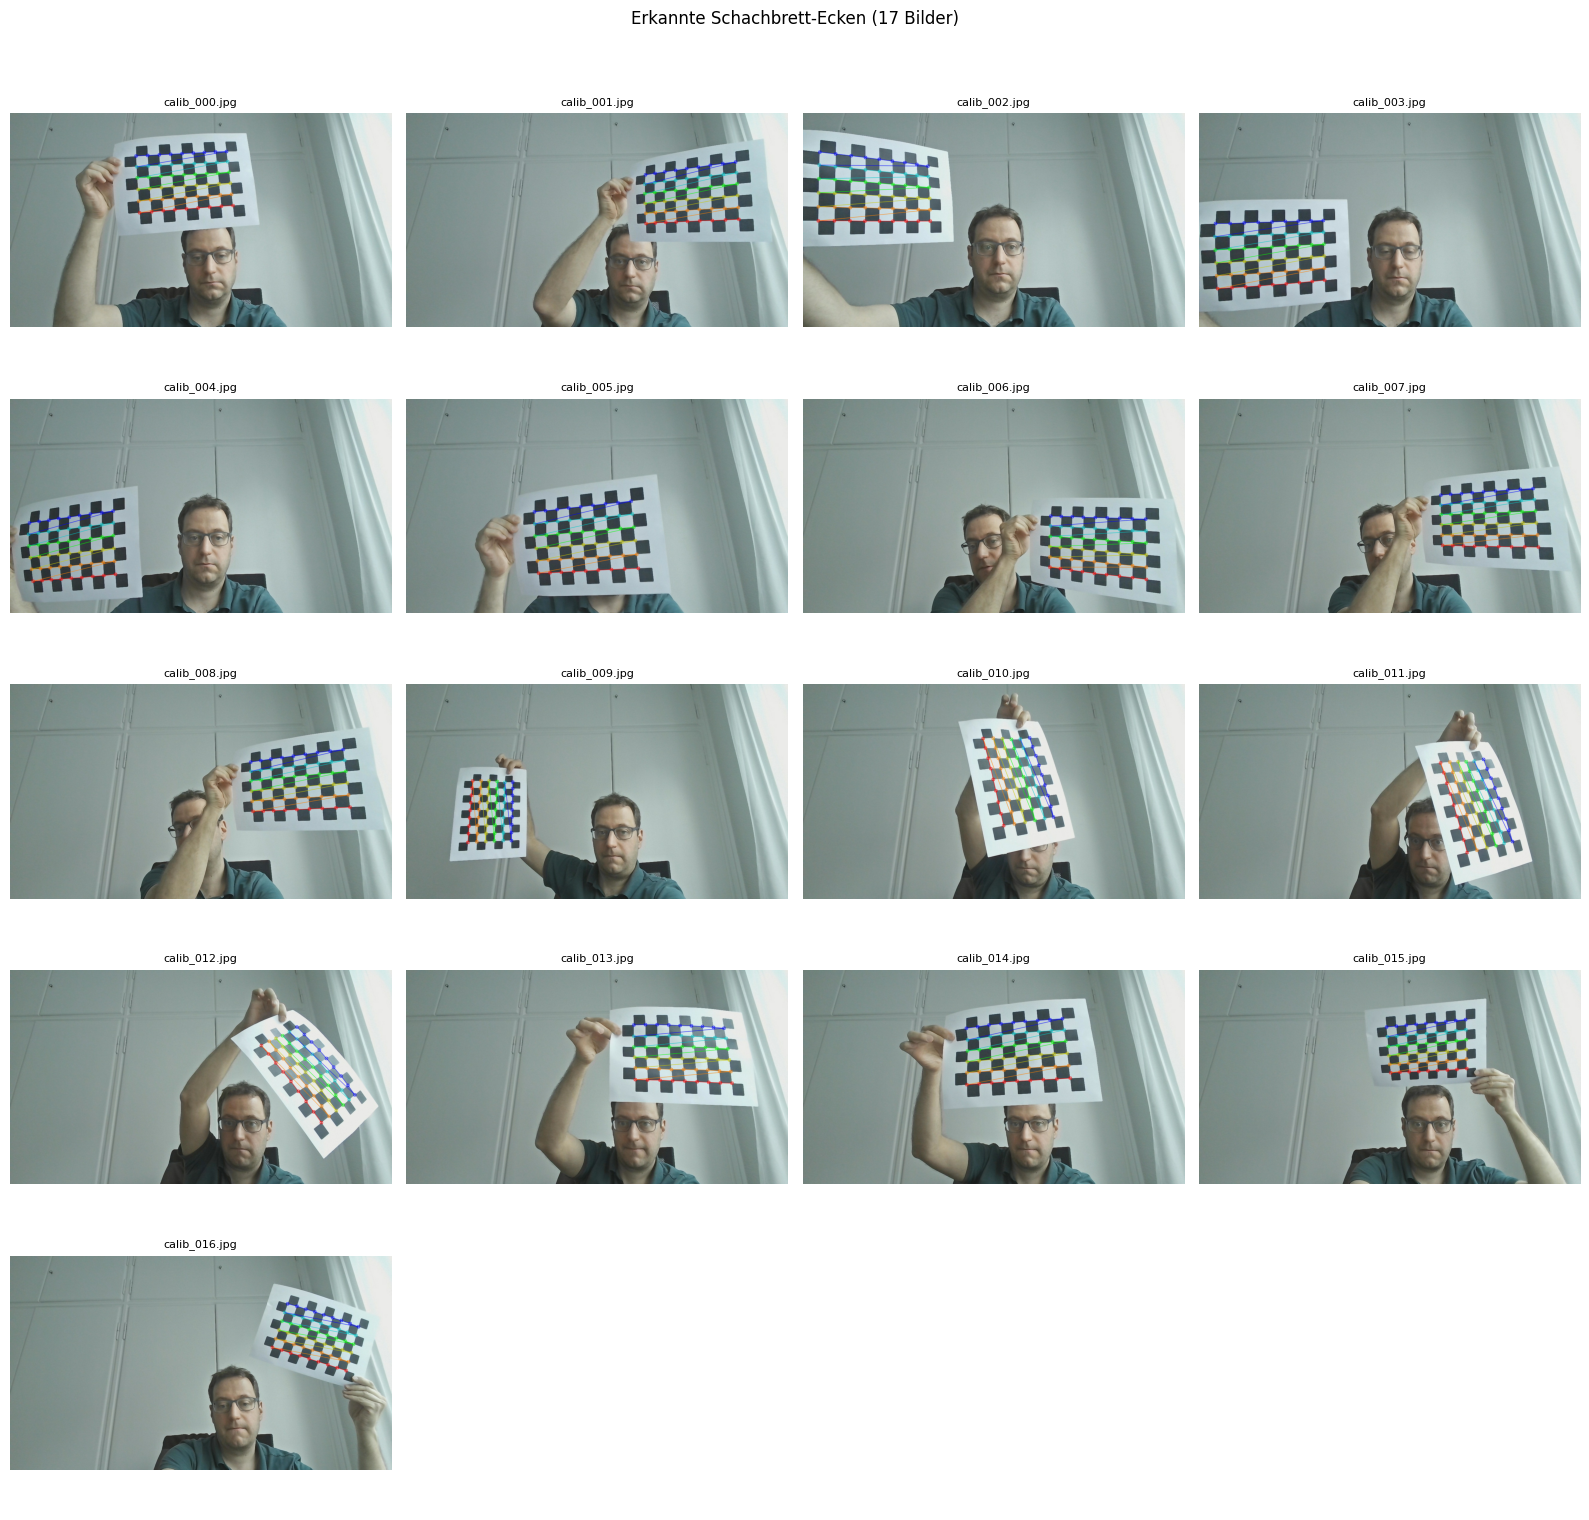


Bildgrösse: 1280 × 720 Pixel


In [ ]:
# Visuelle Übersicht: Erkannte Eckpunkte in allen akzeptierten Bildern
if not accepted:
    print("❌ Keine brauchbaren Bilder gefunden. Bitte neue Bilder aufnehmen (Schritt 2).")
else:
    n     = len(accepted)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = np.array(axes).reshape(-1) if n > 1 else [axes]

    for ax, (fpath, img, corners, _) in zip(axes, accepted):
        vis = img.copy()
        cv2.drawChessboardCorners(vis, BOARD_SIZE, corners, True)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(fpath.name, fontsize=8)
        ax.axis('off')

    # Leere Subplots ausblenden
    for ax in axes[len(accepted):]:
        ax.axis('off')

    plt.suptitle(f"Erkannte Schachbrett-Ecken ({len(accepted)} Bilder)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"\nBildgrösse: {img_size[0]} × {img_size[1]} Pixel")


---
## Schritt 4 – Kalibrierung durchführen

OpenCV löst jetzt ein Optimierungsproblem:
Es sucht die Kameramatrix **K** und die Verzerrungskoeffizienten **dist**,
die den **Reprojektionsfehler** (RMSE) minimieren.


In [ ]:
if len(object_points) < 4:
    print("❌ Zu wenige brauchbare Bilder. Bitte mehr Bilder aufnehmen!")
else:
    print("Kalibrierung läuft...")
    t0 = time.time()

    rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
        object_points, image_points,
        img_size, None, None
    )

    elapsed = time.time() - t0
    print(f"✓ Fertig in {elapsed:.1f} s")
    print()
    print("=" * 55)
    print("  KALIBRIERUNGSERGEBNIS")
    print("=" * 55)
    print(f"  Reprojektionsfehler (RMSE):  {rms:.4f} Pixel")
    quality = "✅ Sehr gut" if rms < 0.5 else ("✅ Gut" if rms < 1.0 else "⚠️  Prüfen – evtl. Bilder wiederholen")
    print(f"  Bewertung:                   {quality}")
    print()
    print("  Kameramatrix K:")
    print(f"    fx = {K[0,0]:.2f} px   fy = {K[1,1]:.2f} px  (Brennweite)")
    print(f"    cx = {K[0,2]:.2f} px   cy = {K[1,2]:.2f} px  (Hauptpunkt)")
    print()
    print("  Verzerrungskoeffizienten:")
    labels = ["k1 (radial)", "k2 (radial)", "p1 (tangential)", "p2 (tangential)", "k3 (radial)"]
    for label, val in zip(labels, dist.ravel()):
        print(f"    {label:<20s} = {val:+.6f}")
    print("=" * 55)


Kalibrierung läuft...
✓ Fertig in 0.7 s

  KALIBRIERUNGSERGEBNIS
  Reprojektionsfehler (RMSE):  1.3374 Pixel
  Bewertung:                   ⚠️  Prüfen – evtl. Bilder wiederholen

  Kameramatrix K:
    fx = 747.96 px   fy = 745.40 px  (Brennweite)
    cx = 606.30 px   cy = 374.20 px  (Hauptpunkt)

  Verzerrungskoeffizienten:
    k1 (radial)          = +0.013690
    k2 (radial)          = -0.096453
    p1 (tangential)      = +0.007204
    p2 (tangential)      = -0.003382
    k3 (radial)          = +0.015939


---
## Schritt 5 – Reprojektionsfehler pro Bild analysieren

Ein hoher Fehler bei einzelnen Bildern deutet auf schlechte Aufnahmequalität hin
(Bewegungsunschärfe, abgeschnittene Ecken, falsche Eckenerkennung).


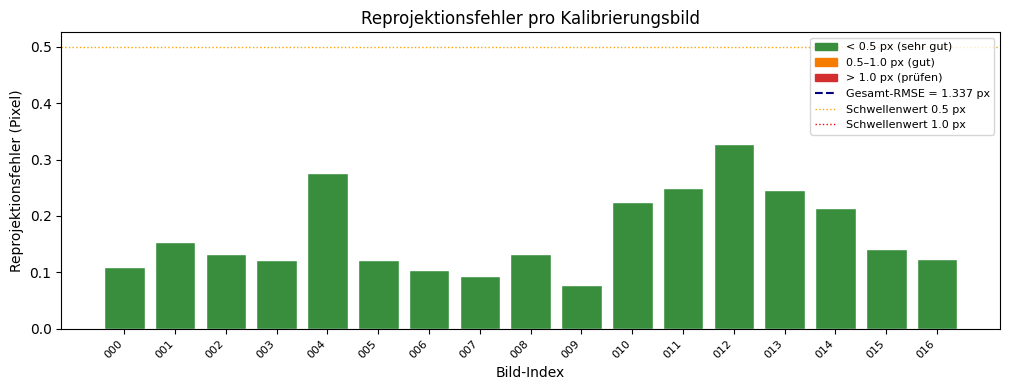

✓ Alle Bilder im grünen Bereich!


In [ ]:
# Reprojektionsfehler für jedes einzelne Bild berechnen
per_image_errors = []

for i, (objpts, imgpts, rvec, tvec) in enumerate(
        zip(object_points, image_points, rvecs, tvecs)):
    projected, _ = cv2.projectPoints(objpts, rvec, tvec, K, dist)
    err = cv2.norm(imgpts, projected, cv2.NORM_L2) / len(projected)
    per_image_errors.append(err)

# Balkendiagramm
fig, ax = plt.subplots(figsize=(max(8, len(accepted) * 0.6), 4))
colors = ['#d32f2f' if e > 1.0 else ('#f57c00' if e > 0.5 else '#388e3c')
          for e in per_image_errors]
bars = ax.bar(range(len(per_image_errors)), per_image_errors, color=colors, edgecolor='white')

ax.axhline(y=rms,  color='navy',   linestyle='--', linewidth=1.5, label=f'Gesamt-RMSE = {rms:.3f} px')
ax.axhline(y=0.5,  color='orange', linestyle=':',  linewidth=1.0, label='Schwellenwert 0.5 px')
ax.axhline(y=1.0,  color='red',    linestyle=':',  linewidth=1.0, label='Schwellenwert 1.0 px')

ax.set_xlabel('Bild-Index')
ax.set_ylabel('Reprojektionsfehler (Pixel)')
ax.set_title('Reprojektionsfehler pro Kalibrierungsbild')
ax.set_xticks(range(len(per_image_errors)))
ax.set_xticklabels([f.name.replace('calib_','').replace('.jpg','')
                    for f, *_ in accepted], rotation=45, ha='right', fontsize=8)

# Legende mit Farbcodes
legend_patches = [
    mpatches.Patch(color='#388e3c', label='< 0.5 px (sehr gut)'),
    mpatches.Patch(color='#f57c00', label='0.5–1.0 px (gut)'),
    mpatches.Patch(color='#d32f2f', label='> 1.0 px (prüfen)'),
]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0][0:3],
          loc='upper right', fontsize=8)
ax.set_ylim(0, max(per_image_errors) * 1.3 + 0.1)

plt.tight_layout()
plt.show()

# Ausreisser identifizieren
outliers = [(i, e, accepted[i][0].name) for i, e in enumerate(per_image_errors) if e > 1.0]
if outliers:
    print("⚠️  Bilder mit hohem Fehler (> 1.0 px) – evtl. neu aufnehmen:")
    for idx, err, name in outliers:
        print(f"   Bild {idx}: {name}  →  Fehler = {err:.3f} px")
else:
    print("✓ Alle Bilder im grünen Bereich!")


---
## Schritt 6 – Kameraparameter verstehen

### Was bedeuten die Parameter für eure Kamera?


Interpretation:
   Bildgroesse:        1280 x 720 Pixel
   Brennweite:         fx=748.0 px  /  fy=745.4 px
   Sichtfeld (FOV):    horizontal 81.1  /  vertikal 51.6
   Hauptpunkt:         (606.3, 374.2)  Bildmitte waere (640.0, 360.0)
   k1 = 0.01369  ->  Tonnenverzerrung



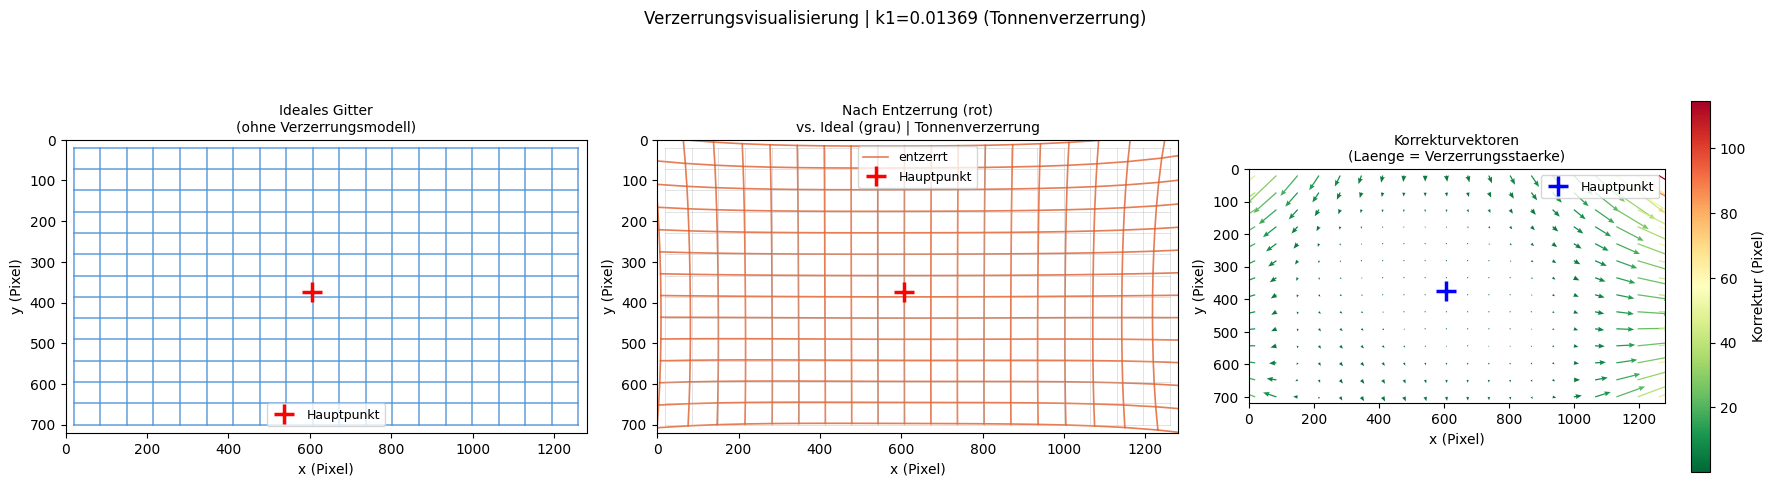

Groesste Korrektur: 114.78 px  (tritt am Bildrand auf)
Mittlere Korrektur: 9.61 px


In [ ]:
fx, fy = K[0,0], K[1,1]
cx, cy = K[0,2], K[1,2]
w_img, h_img = img_size
fov_h = 2 * np.degrees(np.arctan(w_img / (2 * fx)))
fov_v = 2 * np.degrees(np.arctan(h_img / (2 * fy)))
k1    = dist.ravel()[0]

print('Interpretation:')
print(f'   Bildgroesse:        {w_img} x {h_img} Pixel')
print(f'   Brennweite:         fx={fx:.1f} px  /  fy={fy:.1f} px')
print(f'   Sichtfeld (FOV):    horizontal {fov_h:.1f}  /  vertikal {fov_v:.1f}')
print(f'   Hauptpunkt:         ({cx:.1f}, {cy:.1f})  Bildmitte waere ({w_img/2:.1f}, {h_img/2:.1f})')
verzerrung = ('Kissenverzerrung' if k1 < -0.01 else
              'Tonnenverzerrung' if k1 >  0.01 else 'Kaum radiale Verzerrung')
print(f'   k1 = {k1:.5f}  ->  {verzerrung}')
print()

# ── VERZERRUNGSVISUALISIERUNG MIT LINIEN-GITTER ──────────────────────────
GRID_COLS = 20   # Anzahl vertikaler Linien
GRID_ROWS = 14   # Anzahl horizontaler Linien
MARGIN    = 20   # Randabstand in Pixeln

def make_grid_points(cols, rows, w, h, margin):
    """Erzeugt ein regelmaessiges Gitter als (N,1,2) float32-Array."""
    xs = np.linspace(margin, w - margin, cols)
    ys = np.linspace(margin, h - margin, rows)
    pts = np.array([[[x, y]] for y in ys for x in xs], dtype=np.float32)
    return pts, xs, ys

grid_pts, xs, ys = make_grid_points(GRID_COLS, GRID_ROWS, w_img, h_img, MARGIN)

# Punkte entzerren (zeigt, wie das Gitter nach Korrektur aussieht)
undist_pts = cv2.undistortPoints(grid_pts, K, dist, None, K)

def draw_grid_lines(ax, pts_flat, cols, rows, color, lw, alpha, label=None):
    """Verbindet Gitterpunkte zu horizontalen und vertikalen Linien."""
    grid = pts_flat.reshape(rows, cols, 2)
    first = True
    for r in range(rows):
        kw = dict(color=color, lw=lw, alpha=alpha)
        if first and label:
            kw['label'] = label
            first = False
        ax.plot(grid[r, :, 0], grid[r, :, 1], **kw)
    for c in range(cols):
        ax.plot(grid[:, c, 0], grid[:, c, 1],
                color=color, lw=lw, alpha=alpha)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Ideales Gitter ──────────────────────────────────────────────
ax = axes[0]
draw_grid_lines(ax, grid_pts.reshape(-1, 2),
                GRID_COLS, GRID_ROWS, '#4a90d9', 1.2, 0.8)
ax.plot([cx], [cy], 'r+', ms=14, mew=2.5, label='Hauptpunkt')
ax.set_xlim(0, w_img); ax.set_ylim(h_img, 0)
ax.set_aspect('equal')
ax.set_title('Ideales Gitter\n(ohne Verzerrungsmodell)', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlabel('x (Pixel)'); ax.set_ylabel('y (Pixel)')

# ── Panel 2: Entzerrtes Gitter ───────────────────────────────────────────
ax = axes[1]
draw_grid_lines(ax, undist_pts.reshape(-1, 2),
                GRID_COLS, GRID_ROWS, '#e05c2a', 1.2, 0.8, label='entzerrt')
# Ideal als Referenz (grau)
draw_grid_lines(ax, grid_pts.reshape(-1, 2),
                GRID_COLS, GRID_ROWS, '#aaaaaa', 0.6, 0.4)
ax.plot([cx], [cy], 'r+', ms=14, mew=2.5, label='Hauptpunkt')
ax.set_xlim(0, w_img); ax.set_ylim(h_img, 0)
ax.set_aspect('equal')
ax.set_title(f'Nach Entzerrung (rot)\nvs. Ideal (grau) | {verzerrung}', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlabel('x (Pixel)'); ax.set_ylabel('y (Pixel)')

# ── Panel 3: Verschiebungsvektoren (Quiver) ──────────────────────────────
# Zeigt fuer jeden Punkt den Korrekturvektor original -> entzerrt
ax = axes[2]
orig = grid_pts.reshape(-1, 2)
corr = undist_pts.reshape(-1, 2)
dx   = corr[:, 0] - orig[:, 0]
dy   = corr[:, 1] - orig[:, 1]
magnitude = np.sqrt(dx**2 + dy**2)

# Quiver (Pfeile)
q = ax.quiver(orig[:, 0], orig[:, 1], dx, -dy,  # y invertiert fuer Bildkoordinaten
              magnitude, cmap='RdYlGn_r',
              scale=None, scale_units='xy', angles='xy',
              width=0.003, headwidth=4)
plt.colorbar(q, ax=ax, label='Korrektur (Pixel)', shrink=0.85)
ax.plot([cx], [cy], 'b+', ms=14, mew=2.5, label='Hauptpunkt')
ax.set_xlim(0, w_img); ax.set_ylim(h_img, 0)
ax.set_aspect('equal')
ax.set_title('Korrekturvektoren\n(Laenge = Verzerrungsstaerke)', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlabel('x (Pixel)'); ax.set_ylabel('y (Pixel)')

plt.suptitle(
    f'Verzerrungsvisualisierung | k1={k1:.5f} ({verzerrung})',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print(f'Groesste Korrektur: {magnitude.max():.2f} px  (tritt am Bildrand auf)')
print(f'Mittlere Korrektur: {magnitude.mean():.2f} px')


---
## Schritt 7 – Kalibrierparameter speichern

Die Parameter werden als `.npy`-Dateien gespeichert –
genau das Format, das Übung 2 erwartet!


In [ ]:
# Parameter als NumPy-Dateien speichern (kompatibel mit Übung 2)
np.save("camera_matrix.npy",  K)
np.save("dist_coeffs.npy",    dist)

# Auch als menschenlesbares Textformat
with open("kalibration_ergebnis.txt", "w") as f:
    f.write(f"Kamerakalibration – Computer Vision FS 2026\n")
    f.write(f"Aufgenommen: {len(accepted)} Bilder\n")
    f.write(f"Reprojektionsfehler RMSE: {rms:.4f} px\n\n")
    f.write("Kameramatrix K:\n")
    f.write(np.array2string(K, precision=4, suppress_small=True) + "\n\n")
    f.write("Verzerrungskoeffizienten [k1 k2 p1 p2 k3]:\n")
    f.write(np.array2string(dist, precision=6, suppress_small=True) + "\n")

print("✓ Gespeicherte Dateien:")
print("   camera_matrix.npy      → Kameramatrix K")
print("   dist_coeffs.npy        → Verzerrungskoeffizienten")
print("   kalibration_ergebnis.txt → Lesbare Zusammenfassung")
print()

# Kontrollausgabe
K_loaded   = np.load("camera_matrix.npy")
dist_loaded = np.load("dist_coeffs.npy")
print("Kontroll-Laden erfolgreich:")
print(f"  K Shape:    {K_loaded.shape}  | Max-Diff: {np.max(np.abs(K_loaded - K)):.2e}")
print(f"  dist Shape: {dist_loaded.shape} | Max-Diff: {np.max(np.abs(dist_loaded - dist)):.2e}")


✓ Gespeicherte Dateien:
   camera_matrix.npy      → Kameramatrix K
   dist_coeffs.npy        → Verzerrungskoeffizienten
   kalibration_ergebnis.txt → Lesbare Zusammenfassung

Kontroll-Laden erfolgreich:
  K Shape:    (3, 3)  | Max-Diff: 0.00e+00
  dist Shape: (1, 5) | Max-Diff: 0.00e+00


---
## Schritt 8 – Live-Entzerrung der Kamera

Jetzt wird die Kalibrierung in Echtzeit angewendet!
Haltet das Schachbrettmuster erneut in die Kamera und beobachtet,
wie die Verzerrung verschwindet.

**Bedienung:** `[s]` Screenshot speichern &nbsp;|&nbsp; `[q]` Beenden


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LIVE-ENTZERRUNG mit gesplittetem Vergleich (links = verzerrt, rechts = entzerrt)
# ══════════════════════════════════════════════════════════════════════════════

# Optimierte Kameramatrix (minimiert schwarze Ränder)
K_opt, roi = cv2.getOptimalNewCameraMatrix(K, dist, img_size, alpha=0.5, newImgSize=img_size)

# Lookup-Maps vorberechnen (effizient für Video)
map1, map2 = cv2.initUndistortRectifyMap(K, dist, None, K_opt, img_size, cv2.CV_32FC1)

cap = cv2.VideoCapture(CAMERA_INDEX)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  img_size[0])
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, img_size[1])

screenshot_count = 0
w, h = img_size

if not cap.isOpened():
    print("❌ Kamera nicht gefunden.")
else:
    print("Live-Entzerrung gestartet.")
    print("  [s] Screenshot  |  [q] Beenden")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Entzerrung anwenden
        undistorted = cv2.remap(frame, map1, map2, cv2.INTER_LINEAR)

        # Split-Ansicht: links verzerrt, rechts entzerrt
        split_x     = w // 2
        left_half   = frame[:, :split_x]
        right_half  = undistorted[:, split_x:]
        comparison  = np.concatenate([left_half, right_half], axis=1)

        # Trennlinie
        cv2.line(comparison, (split_x, 0), (split_x, h), (255, 255, 255), 2)

        # Beschriftungen
        overlay = comparison.copy()
        for rect_x, txt in [(0, "ORIGINAL (verzerrt)"),
                             (split_x + 5, "ENTZERRT (kalibriert)")]:
            cv2.rectangle(overlay, (rect_x, 0), (rect_x + 280, 42), (20, 20, 20), -1)
        cv2.addWeighted(overlay, 0.7, comparison, 0.3, 0, comparison)
        cv2.putText(comparison, "ORIGINAL (verzerrt)",
                    (8, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (80, 80, 255), 2)
        cv2.putText(comparison, "ENTZERRT (kalibriert)",
                    (split_x + 8, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (80, 255, 80), 2)

        # RMSE einblenden
        cv2.putText(comparison, f"RMSE = {rms:.3f} px",
                    (w - 210, h - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (200, 200, 200), 1)

        cv2.imshow("Live-Entzerrung  [s]=Screenshot  [q]=Beenden", comparison)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('s'):
            fname = f"entzerrt_screenshot_{screenshot_count:02d}.jpg"
            cv2.imwrite(fname, undistorted)
            screenshot_count += 1
            print(f"  📸 Screenshot gespeichert: {fname}")

    cap.release()
    cv2.destroyAllWindows()
    print("Live-Ansicht beendet.")


Live-Entzerrung gestartet.
  [s] Screenshot  |  [q] Beenden
Live-Ansicht beendet.


---
## Schritt 9 – Letztes Kalibrierbild: Vergleich Original vs. Entzerrt


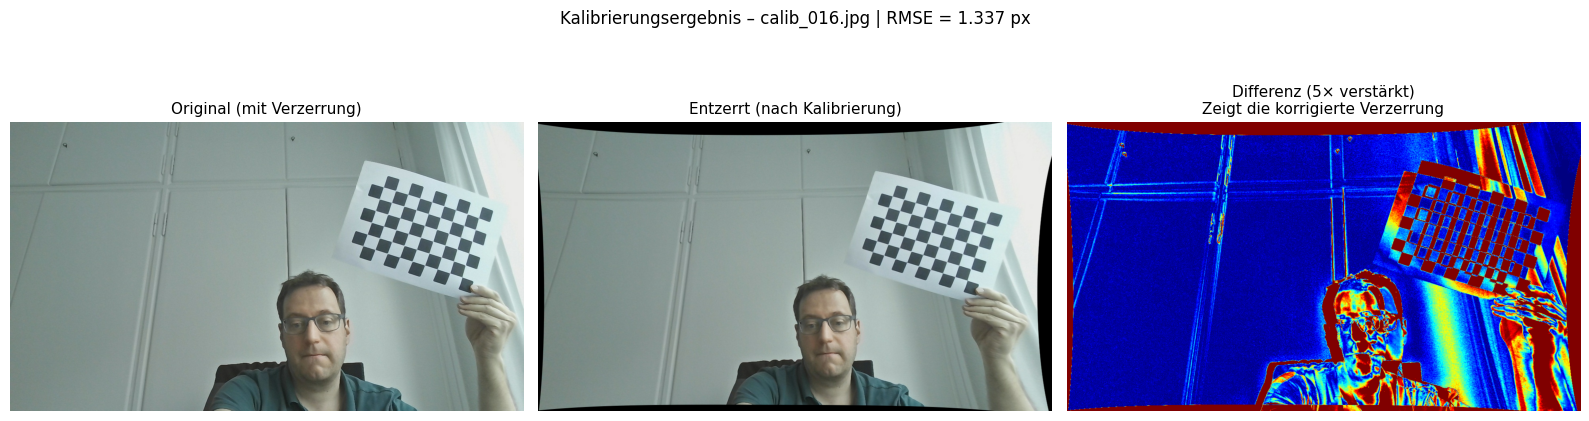

Das Differenzbild zeigt, wo die Verzerrungskorrektur den grössten Effekt hat.
(Typischerweise an den Bildrändern bei radialer Verzerrung.)


In [ ]:
if accepted:
    # Letztes Kalibrierbild als Vergleich
    last_path, last_img, _, _ = accepted[-1]
    undistorted_last = cv2.remap(last_img, map1, map2, cv2.INTER_LINEAR)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(cv2.cvtColor(last_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original (mit Verzerrung)", fontsize=11)

    axes[1].imshow(cv2.cvtColor(undistorted_last, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Entzerrt (nach Kalibrierung)", fontsize=11)

    # Differenzbild (Verzerrungseffekt sichtbar machen)
    diff = cv2.absdiff(last_img, undistorted_last)
    diff_enhanced = cv2.applyColorMap(
        cv2.convertScaleAbs(diff, alpha=5), cv2.COLORMAP_JET)
    axes[2].imshow(cv2.cvtColor(diff_enhanced, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Differenz (5× verstärkt)\nZeigt die korrigierte Verzerrung", fontsize=11)

    for ax in axes:
        ax.axis('off')

    plt.suptitle(f"Kalibrierungsergebnis – {last_path.name} | RMSE = {rms:.3f} px",
                 fontsize=12)
    plt.tight_layout()
    plt.show()
    print("Das Differenzbild zeigt, wo die Verzerrungskorrektur den grössten Effekt hat.")
    print("(Typischerweise an den Bildrändern bei radialer Verzerrung.)")


---
## Schritt 10 – Reflexionsfragen 🤔

Beantwortet die folgenden Fragen gemeinsam mit eurer Partnerin / eurem Partner:

1. **Reprojektionsfehler:** Wie gross ist euer RMSE?
   Was könnte ein Wert über 1.0 px bedeuten – was würdet ihr tun?

2. **Hauptpunkt:** Liegt euer Hauptpunkt (cx, cy) in der Nähe der Bildmitte?
   Was würde ein stark verschobener Hauptpunkt bedeuten?

3. **Verzerrungstyp:** Haben eure Parameter k1 > 0 oder k1 < 0?
   Welchen Verzerrungstyp zeigt eure Kamera (Tonne oder Kissen)?

4. **Anzahl Bilder:** Was passiert, wenn ihr die Kalibrierung mit nur 5 Bildern wiederholt?
   (Bonus: Probiert es aus und vergleicht den RMSE!)

5. **Differenzbild:** Wo ist der Korrektureffekt am stärksten?
   Warum genau dort?

---
## 📁 Zusammenfassung der erzeugten Dateien

| Datei | Inhalt | Verwendung |
|---|---|---|
| `camera_matrix.npy` | Kameramatrix K (3×3) | Übung 2, eigene Projekte |
| `dist_coeffs.npy` | Verzerrungskoeff. (1×5) | Übung 2, eigene Projekte |
| `kalibration_ergebnis.txt` | Lesbare Zusammenfassung | Dokumentation |
| `kalibrier_bilder/` | Alle Aufnahmebilder | Kontroll, Wiederholung |
| `entzerrt_screenshot_*.jpg` | Live-Entzerrungsaufnahmen | Präsentation |

> **Für Übung 2:** Kopiert `camera_matrix.npy` und `dist_coeffs.npy`
> in dasselbe Verzeichnis wie `Ü2_Kalib.ipynb` – dann werden sie automatisch geladen.
